# Topic modelling 

This workbook implements topic modelling. 

It first pre-processes the text. This first consists of performing named entity recognition (NER) - utilising the pre-trained HuggingFace model ([reddit-ner-place-names](https://huggingface.co/cjber/reddit-ner-place_names) developed by Cillian Berragan at Liverpool uni. Then, I remove stop words, punctuation and lemmatize the text. 

Topic modelling is carried out using various methods and compared. This includes:
* Latent dirichlet allocation (LDA)
* Latent semantic analysis (LSA)
* bertopic 

In [1]:
import pandas as pd
import numpy as np
import re
import string 
from datasets import Dataset

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from scipy.cluster import hierarchy as sch

from transformers import AutoModelForMaskedLM, pipeline, AutoTokenizer

from bertopic import BERTopic

import nltk 
from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from gensim import corpora
from gensim.models import LdaModel
from gensim.models import LsiModel
from gensim.models import HdpModel
from gensim.models import TfidfModel

/opt/miniconda3/envs/nlp_env_analysis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to /Users/bea/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/bea/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/bea/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Start by loading the data - this is a small chunk of data which has been scraped. 

In [2]:
# Load data
train_df = pd.read_csv('../outputs/train_comments.csv')
test_df = pd.read_csv('../outputs/test_comments.csv')

# Convert DataFrame to Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [3]:
print(f'Number of comments in training dataset: {len(train_dataset)} \nNumber of comments in test dataset: {len(test_dataset)}')

Number of comments in training dataset: 542 
Number of comments in test dataset: 136


In [4]:
text = list(train_df['comment_text'])

In [5]:
# define the model 
# model = AutoModelForMaskedLM.from_pretrained("../outputs/nlp_fine_tuning/distilbert-base-uncased")

model_checkpoint = "distilbert-base-uncased"
model = AutoModelForMaskedLM.from_pretrained(model_checkpoint)

## Chunking - approaches to limit the number of tokens

Split the text in various ways to parse ins smaller formats. 

In [6]:
print(f'Number of comments in training dataset: {len(text)}')

Number of comments in training dataset: 542


First, visualise the distribution of token length.

In [9]:
# define the model 
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_function(examples):
    result = tokenizer(examples["comment_text"])
    if tokenizer.is_fast:
        result["word_ids"] = [result.word_ids(i) for i in range(len(result["input_ids"]))]
    return result

tokenized_datasets = train_dataset.map(tokenize_function, batched=True, remove_columns=["address", "stance", "date", "comment_text"])

Map: 100%|██████████| 542/542 [00:00<00:00, 4957.60 examples/s]


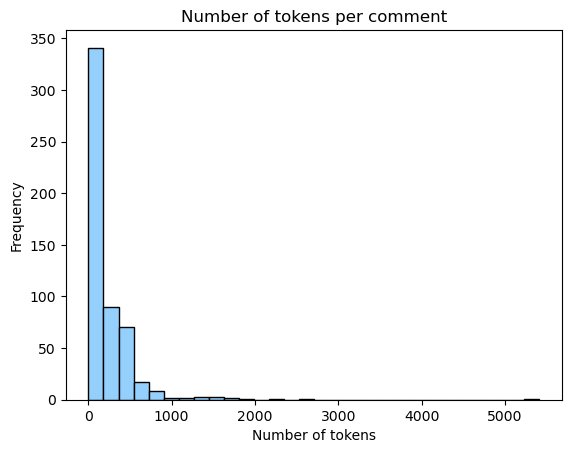

In [10]:
# Extract the number of tokens for each item in tokenized_datasets
num_tokens = [len(item["input_ids"]) for item in tokenized_datasets]

# Plot the histogram
plt.hist(num_tokens, bins=30, color='xkcd:light blue', edgecolor='black')
plt.title("Number of tokens per comment")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.show()

Now for the chunking - split the chunks according to line-down, which is denoted by '\n' in HTML.

In [11]:
# some pre-processing 
text = [sentence.split('\n') for sentence in text]
text = [item for sublist in text for item in sublist]
text = [sentence.replace('\n', '') for sentence in text]

# remove empty strings from the list
text = list(filter(None, text))

In [12]:
print(f'Number of chunked comments in training dataset: {len(text)}')

Number of chunked comments in training dataset: 2508


Visualise the distribution of tokens in the freshly chunked data.

Map: 100%|██████████| 2508/2508 [00:00<00:00, 14486.50 examples/s]


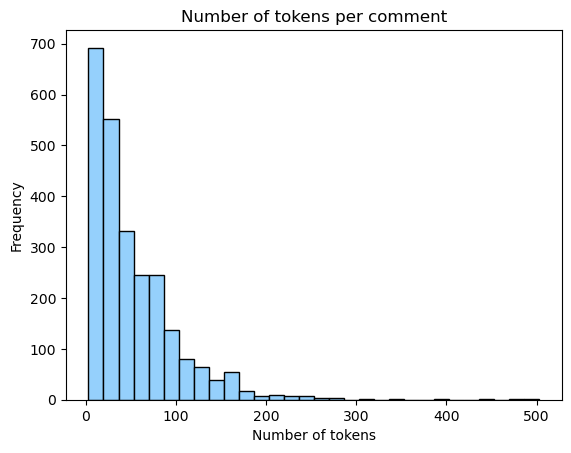

In [13]:
chunk_text = Dataset.from_dict({'comment_text':text})

# Use batched=True to activate fast multithreading!
chunk_text = chunk_text.map(tokenize_function, batched=True)

# Extract the number of tokens for each item in tokenized_datasets
num_tokens = [len(item["input_ids"]) for item in chunk_text]

# Plot the histogram
plt.hist(num_tokens, bins=30, color='xkcd:light blue', edgecolor='black')
plt.title("Number of tokens per comment")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.show()

In [14]:
max_length_tokens = 300 #512
min_length_tokens = 5

num_long_chunks = sum(len(item["input_ids"]) > max_length_tokens for item in chunk_text)
print(f"Number of items with tokens > {max_length_tokens}: {num_long_chunks}")

num_short_chunks = sum(len(item["input_ids"]) < min_length_tokens for item in chunk_text)
print(f"Number of items with tokens < {min_length_tokens}: {num_short_chunks}")

Number of items with tokens > 300: 9
Number of items with tokens < 5: 84


In [15]:
# Find indices of items with input_ids length greater than max_length_tokens
below_indices = [i for i, item in enumerate(chunk_text) if len(item["input_ids"]) < 4]

# Print the comment_text for those indices
for idx in below_indices:
    print(f"Index: {idx}, Comment Text: {chunk_text['comment_text'][idx]}")

Index: 248, Comment Text: Consultation
Index: 256, Comment Text: Policies
Index: 267, Comment Text: Design
Index: 285, Comment Text: Housing
Index: 306, Comment Text: Conclusions
Index: 344, Comment Text: Shocked
Index: 371, Comment Text: Object
Index: 393, Comment Text: Thanks
Index: 823, Comment Text: yours
Index: 854, Comment Text: Regards
Index: 956, Comment Text: Thanks
Index: 1073, Comment Text: Noise
Index: 1182, Comment Text: Object
Index: 1215, Comment Text: Chair
Index: 1327, Comment Text: Landscaping
Index: 1481, Comment Text: .
Index: 1514, Comment Text: TELEPHONE
Index: 1543, Comment Text: Reason
Index: 1548, Comment Text: Traffic
Index: 1557, Comment Text: Traffic
Index: 1570, Comment Text: Conditions
Index: 1943, Comment Text: ¿
Index: 1944, Comment Text: ¿
Index: 2140, Comment Text: Object
Index: 2275, Comment Text: Best
Index: 2276, Comment Text: Alice


In [16]:
# Remove items at indices in below_indices
text = [text[i] for i in range(len(text)) if i not in below_indices]

## Baseline topic modelling acheived with BertTopic and minimal pre-processing 

This uses the pretrained domain knowledge model which was an output of 1_0_1_domain_knowledge_nlp.ipynb

In [17]:
topic_model = BERTopic(embedding_model=model)
topics, probs = topic_model.fit_transform(text)

topic_model.get_topic_info()[:10]

,Topic,Count,Name,Representation,Representative_Docs
0,-1,587,-1_the_of_and_to,"[the, of, and, to, this, in, is, community, fo...",[As a neighbour I object to this proposed buil...
1,0,135,0_wharf_royal_green_the,"[wharf, royal, green, the, this, in, already, ...",[The area is already getting very crowded with...
2,1,110,1_housing_affordable_newham_in,"[housing, affordable, newham, in, development,...",[Housing is in dire need throughout all of New...
3,2,94,2_community_space_reduction_for,"[community, space, reduction, for, groups, use...","[Third, the significant reduction of community..."
4,3,77,3_ballymore_green_space_wharf,"[ballymore, green, space, wharf, this, royal, ...",[Loss of amenity: Owners at Royal Wharf were s...
5,4,77,4_access_fishguard_felixstowe_way,"[access, fishguard, felixstowe, way, will, sub...",[1) It is planned to access the development th...
6,5,73,5_green_space_more_was,"[green, space, more, was, area, development, s...",[This should be a green space as advertised at...
7,6,72,6_height_street_high_design,"[height, street, high, design, is, area, the, ...","[I strongly object to the proposals. First, th..."
8,7,64,7_noise_dust_pollution_airport,"[noise, dust, pollution, airport, construction...",[Noise pollution - due to construction and fut...
9,8,63,8_parking_car_already_spaces,"[parking, car, already, spaces, park, cars, in...",[8) Insufficient provision of car parking. As ...


## Removing geographic place names using named entity recognition 
I don't want the topics identified to relate to the place names of specific applications (i.e. Durning Hall or Forest Gate) - as I want the topics to be generalised themes, common across applications - hence I remove all place names. This uses Named Entity Recognition (NER), I intially tried using the out of the box bog-standard model, but it wasn't able to recognise more specific British place names. Instead I use the "cjber/reddit-ner-place_names" - which has specifically been trained to recognise these sorts of place names. 

In [18]:
ner_pipeline = pipeline(
    task="ner",
    model="cjber/reddit-ner-place_names",
    tokenizer="cjber/reddit-ner-place_names",
    aggregation_strategy="first",
)

Device set to use mps:0


In [19]:
def remove_locations(text):
    ner_results = ner_pipeline(text)

    # Sort entities by their start index in descending order to avoid index shifting
    ner_results = sorted(ner_results, key=lambda x: x["start"], reverse=True)
    
    # Remove locations by replacing them with an empty string
    for entity in ner_results:
        text = text[:entity["start"]] + text[entity["end"]:]  # Slice out the location

    # Remove extra spaces caused by deletion
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def remove_place_names(text):

    cleaned_text = [remove_locations(short_text) for short_text in text]
    return cleaned_text

In [20]:
def remove_numbers(text):
    text = [re.sub(r'\d+', '', single_text) for single_text in text]
    # remove extra spaces
    text = [re.sub(r'\s+', ' ', single_text).strip() for single_text in text]

    return text

In [21]:
print(text[1578:1580])

print(remove_place_names(text[1578:1580]))

['1) It is planned to access the development through Fishguard Way and Felixstowe Court. This will have a substantial impact for residents during construction and will increase traffic flow subsequently as it will be the main access for the proposed new buildings. This will create noise pollution, congestion and a general loss of amenity to residents and is likely to cause additional parking issues on estate roads.', '2) Health and safety: Concerns namely traffic pinch point from Fishguard Way and Felixstowe Court. Freehold property (Road) extending some 350 meters long and an entrance of only 6 meters wide, is not designed for heavy construction vehicle movement. The traffic study suggests a vast increase in traffic movement during development. The Freehold Company is currently in discussions with the developers as to the rights of passage over the estate roads.']
['1) It is planned to access the development through and . This will have a substantial impact for residents during constr

In [22]:
cleaned_place_text = remove_place_names(text)
cleaned_place_text = remove_numbers(cleaned_place_text)

### Repeat BertTopic modelling with geographic place names removed 

This uses the same fine-tuned huggingface model fine-tuned to have domain specific knowledge from earlier. 

In [23]:
topic_model_no_place = BERTopic(embedding_model=model)
topics, probs = topic_model_no_place.fit_transform(cleaned_place_text)

topic_model_no_place.get_topic_info()[:10]

,Topic,Count,Name,Representation,Representative_Docs
0,-1,646,-1_and_to_the_this,"[and, to, the, this, of, for, is, in, communit...",[) It is planned to access the development thr...
1,0,165,0_green_space_was_this,"[green, space, was, this, would, more, of, dev...",[Loss of amenity: Owners at were sold on the s...
2,1,120,1_sunlight_daylight_privacy_building,"[sunlight, daylight, privacy, building, light,...","[Unsurprisingly, there is also a significant e..."
3,2,108,2_height_street_high_the,"[height, street, high, the, of, area, design, ...","[I strongly object to the proposals. First, th..."
4,3,80,3_community_space_for_is,"[community, space, for, is, groups, activities...","[Third, the significant reduction of community..."
5,4,75,4_parking_car_spaces_already,"[parking, car, spaces, already, park, provisio...",[Insufficient provision of car parking. As par...
6,5,71,5_school_children_nursery_construction,"[school, children, nursery, construction, dust...","[Construction noise, dust and disruption. The ..."
7,6,63,6_housing_affordable_flats_area,"[housing, affordable, flats, area, local, in, ...",[I noted that there were to be affordable unit...
8,7,56,7_pipes_system_diverted_angles,"[pipes, system, diverted, angles, sewer, repai...",[) Concern of utilities being diverted. The pl...
9,8,55,8_noise_plant_acoustic_db,"[noise, plant, acoustic, db, vibration, levels...",[Where the proposed residential use is in a bu...


In [24]:
topic_model_no_place.visualize_topics()

In [25]:
topic_model_no_place.visualize_heatmap()

In [26]:
# Hierarchical topics
linkage_function = lambda x: sch.linkage(x, 'single', optimal_ordering=True)
hierarchical_topics = topic_model_no_place.hierarchical_topics(cleaned_place_text, linkage_function=linkage_function)

100%|██████████| 50/50 [00:00<00:00, 734.79it/s]


In [27]:
topic_model_no_place.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

## Different types of topic modelling: Latent Dirichlet Allocation

Latent dirichlet allocation uses bag of words to assign topics - so is not sensitive to the sequence of words, or the way sentences or comments are constructed. 

We start with some additional pre-processing, wherby we remove stop words (if, the, then...), remove all punctuation (.,:...), and also lemmatise (churches -> church, ...).

In [29]:
# use nltk to remove stopwords, punctuation and lemmatize the text
stop = set(stopwords.words('english'))
exclude = set(string.punctuation)
lemma = WordNetLemmatizer()

def clean(doc):
    stop_free = " ".join([i for i in doc.lower().split() if i not in stop])
    punc_free = ''.join(ch for ch in stop_free if ch not in exclude)
    normalized = " ".join(lemma.lemmatize(word) for word in punc_free.split())
    return normalized

text_clean = [clean(doc).split() for doc in cleaned_place_text]

In [30]:
text[1578:1581]

['1) It is planned to access the development through Fishguard Way and Felixstowe Court. This will have a substantial impact for residents during construction and will increase traffic flow subsequently as it will be the main access for the proposed new buildings. This will create noise pollution, congestion and a general loss of amenity to residents and is likely to cause additional parking issues on estate roads.',
 '2) Health and safety: Concerns namely traffic pinch point from Fishguard Way and Felixstowe Court. Freehold property (Road) extending some 350 meters long and an entrance of only 6 meters wide, is not designed for heavy construction vehicle movement. The traffic study suggests a vast increase in traffic movement during development. The Freehold Company is currently in discussions with the developers as to the rights of passage over the estate roads.',
 '3) The planning application submitted suggests use of the water way to decrease construction traffic will be reviewed a

In [31]:
text_clean[1578:1581]

[['planned',
  'access',
  'development',
  'substantial',
  'impact',
  'resident',
  'construction',
  'increase',
  'traffic',
  'flow',
  'subsequently',
  'main',
  'access',
  'proposed',
  'new',
  'building',
  'create',
  'noise',
  'pollution',
  'congestion',
  'general',
  'loss',
  'amenity',
  'resident',
  'likely',
  'cause',
  'additional',
  'parking',
  'issue',
  'estate',
  'road'],
 ['health',
  'safety',
  'concern',
  'namely',
  'traffic',
  'pinch',
  'point',
  'freehold',
  'property',
  'road',
  'extending',
  'meter',
  'long',
  'entrance',
  'meter',
  'wide',
  'designed',
  'heavy',
  'construction',
  'vehicle',
  'movement',
  'traffic',
  'study',
  'suggests',
  'vast',
  'increase',
  'traffic',
  'movement',
  'development',
  'freehold',
  'company',
  'currently',
  'discussion',
  'developer',
  'right',
  'passage',
  'estate',
  'road'],
 ['planning',
  'application',
  'submitted',
  'suggests',
  'use',
  'water',
  'way',
  'decrease',
 

Convert the imput to a term-document matrix. This is a matrix which counts the occurrence of every term in each document and normalises the counts to create a matrix of values which can be used for LSA or LDA. 

In [32]:
# Create document-term matrix
dictionary = corpora.Dictionary(text_clean)
doc_term_matrix = [dictionary.doc2bow(doc) for doc in text_clean] 

# Convert sparse to dense format
dense_matrix = [[tup[1] for tup in dictionary.doc2bow(doc)] for doc in text_clean]

In [33]:
# LDA model 
lda = LdaModel(doc_term_matrix, num_topics=10, id2word = dictionary, passes=50)

In [34]:
# print LDA topics as list 

lda_topics = lda.print_topics(num_topics=10, num_words=7)
lda_topics = [topic[1] for topic in lda_topics]
lda_topics = [topic.split('"') for topic in lda_topics]
lda_topics = [[word for word in topic if word.isalpha()] for topic in lda_topics]

for i, topic in enumerate(lda_topics):
    print(f"Topic {i}: {topic}")

Topic 0: ['development', 'letter', 'support', 'june', 'th', 'objection', 'dated']
Topic 1: ['space', 'need', 'community', 'would', 'plan', 'people', 'year']
Topic 2: ['resident', 'access', 'parking', 'development', 'proposed', 'building', 'issue']
Topic 3: ['noise', 'traffic', 'pollution', 'construction', 'development', 'vehicle', 'road']
Topic 4: ['planning', 'use', 'application', 'way', 'site', 'water', 'subject']
Topic 5: ['building', 'proposed', 'would', 'new', 'property', 'light', 'residential']
Topic 6: ['air', 'quality', 'plant', 'policy', 'neutral', 'report', 'please']
Topic 7: ['system', 'pipe', 'concern', 'right', 'angle', 'diverted', 'sewer']
Topic 8: ['area', 'development', 'already', 'building', 'object', 'local', 'space']
Topic 9: ['space', 'community', 'green', 'school', 'would', 'child', 'development']
